In [1]:
!pip install tensorflow openpyxl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob, os

In [3]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, r2_score

from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import LSTM, Dense

In [4]:

from tensorflow.keras.callbacks import EarlyStopping

In [5]:
data_folder   = r"/content"
output_folder = r"/content"

os.makedirs(output_folder, exist_ok=True)

files = glob.glob(os.path.join(data_folder, "RevenueCenter_*.xlsx"))

In [6]:
# Error matrix
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

In [7]:
def create_sequences(series, window=30):
    X, y = [], []
    for i in range(len(series) - window):
        X.append(series[i:i+window])
        y.append(series[i+window])
    return np.array(X), np.array(y)



Processing: RevenueCenter_2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - loss: 0.0292 - val_loss: 0.0552
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 781ms/step - loss: 0.0227 - val_loss: 0.0254
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 195ms/step - loss: 0.0155 - val_loss: 0.0203
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 196ms/step - loss: 0.0163 - val_loss: 0.0264
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 190ms/step - loss: 0.0167 - val_loss: 0.0306
Epoch 6/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 281ms/step - loss: 0.0175 - val_loss: 0.0307
Epoch 7/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 190ms/step - loss: 0.0173 - val_loss: 0.0283
Epoch 8/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 195ms/step - loss: 0.0161 - val_loss: 0.0254
Epoch 9/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 188ms/step - loss: 0.0154 - val_loss: 0.0236
Epoch 10/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 199ms/step - loss: 0.0164 - val_loss: 0.0237
Epoch 11/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 191ms/step - loss: 0.0156 - val_loss: 0.0250
Epoch 12/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 197ms/step - loss: 0.0179

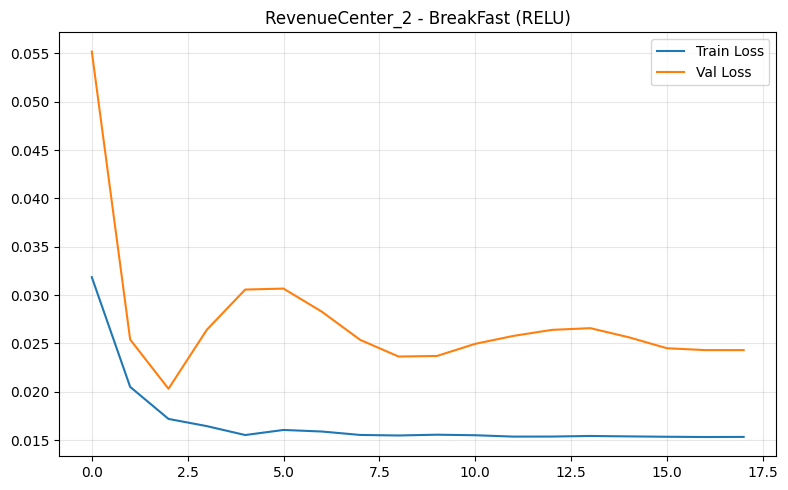

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


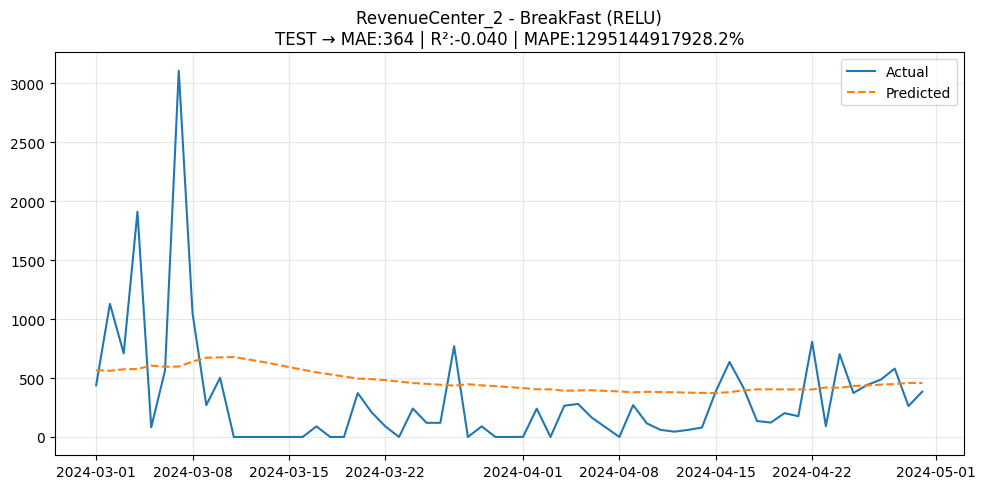

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 14s 339ms/step - loss: 0.0408 - val_loss: 0.1015
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 196ms/step - loss: 0.0225 - val_loss: 0.0561
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 207ms/step - loss: 0.0184 - val_loss: 0.0523
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 201ms/step - loss: 0.0168 - val_loss: 0.0621
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 197ms/step - loss: 0.0162 - val_loss: 0.0686
Epoch 6/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 203ms/step - loss: 0.0176 - val_loss: 0.0686
Epoch 7/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 206ms/step - loss: 0.0172 - val_loss: 0.0651
Epoch 8/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 207ms/step - loss: 0.0160 - val_loss: 0.0603
Epoch 9/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 196ms/step - loss: 0.0159 - val_loss: 0.0574
Epoch 10/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 198ms/step - loss: 0.0138 - val_loss: 0.0572
Epoch 11/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 211ms/step - loss: 0.0155 - val_loss: 0.0594
Epoch 12/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 200ms/step - loss: 0.0151 - val_l

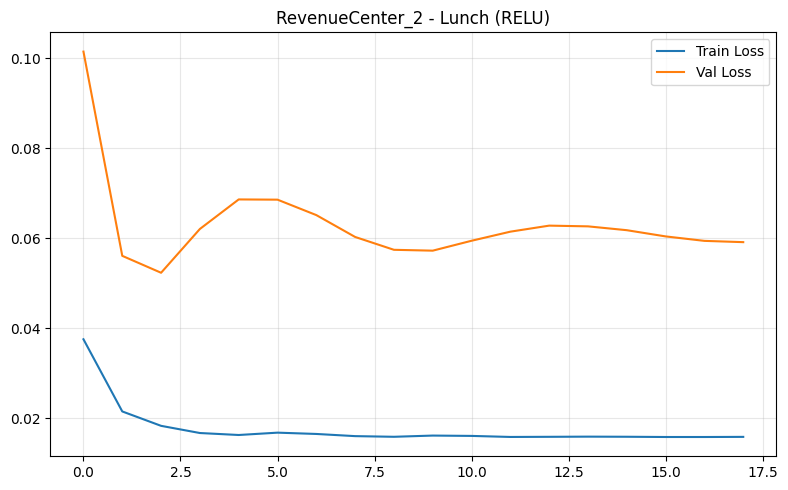

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


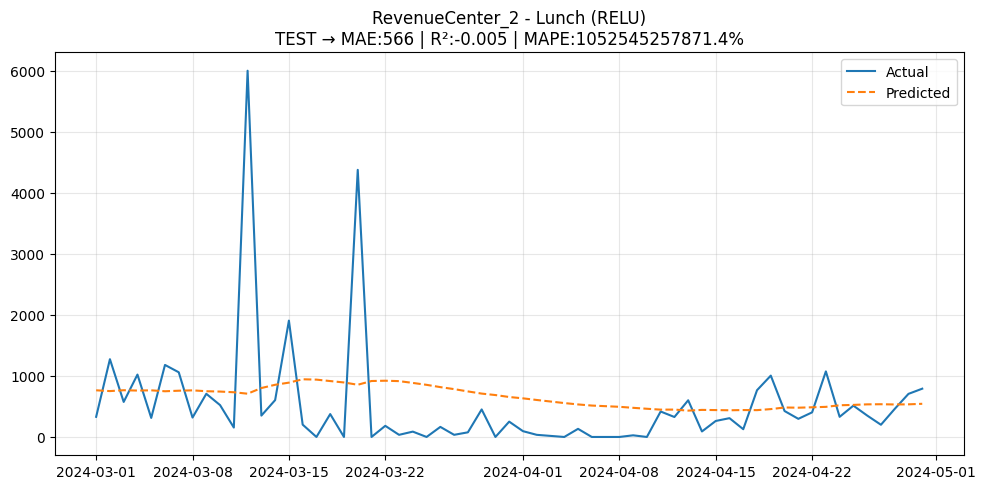

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 327ms/step - loss: 0.0032 - val_loss: 0.0277
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 205ms/step - loss: 0.0019 - val_loss: 0.0253
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 195ms/step - loss: 0.0020 - val_loss: 0.0274
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 212ms/step - loss: 0.0019 - val_loss: 0.0285
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 197ms/step - loss: 0.0020 - val_loss: 0.0282
Epoch 6/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 193ms/step - loss: 0.0017 - val_loss: 0.0275
Epoch 7/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 204ms/step - loss: 0.0020 - val_loss: 0.0268
Epoch 8/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 356ms/step - loss: 0.0018 - val_loss: 0.0267
Epoch 9/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 349ms/step - loss: 0.0018 - val_loss: 0.0271
Epoch 10/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 278ms/step - loss: 0.0016 - val_loss: 0.0276
Epoch 11/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 192ms/step - loss: 0.0019 - val_loss: 0.0278
Epoch 12/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 199ms/step - loss: 0.0022 - val_lo

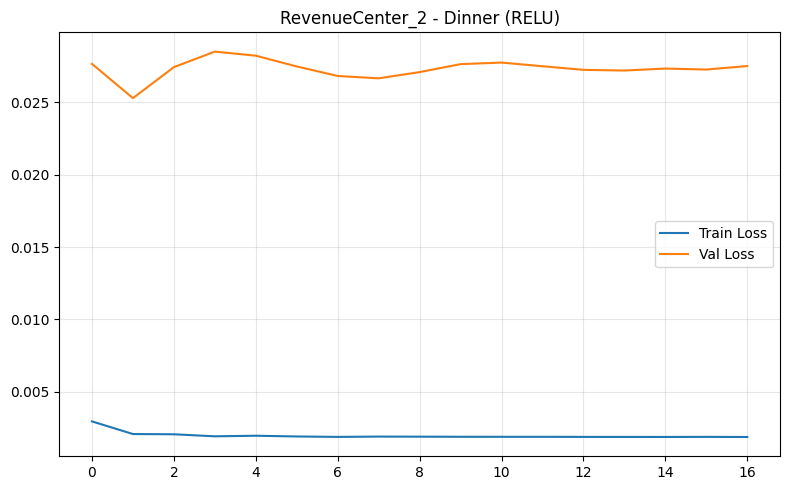

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


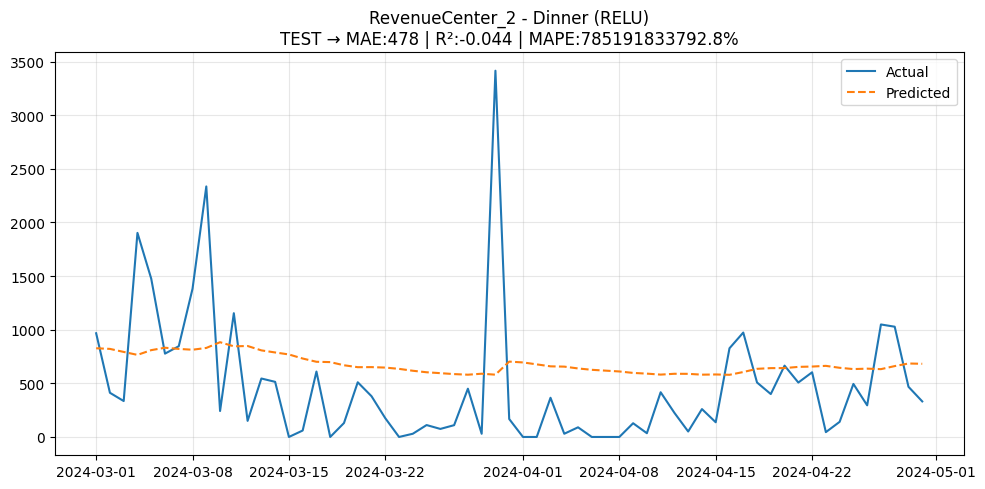

Saved: /content/RevenueCenter_2

Processing: RevenueCenter_8
Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 308ms/step - loss: 0.0104 - val_loss: 0.0027
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 171ms/step - loss: 0.0097 - val_loss: 0.0026
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 248ms/step - loss: 0.0100 - val_loss: 0.0023
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 318ms/step - loss: 0.0100 - val_loss: 0.0023
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 329ms/step - loss: 0.0080 - val_loss: 0.0023
Epoch 6/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 179ms/step - loss: 0.0079 - val_loss: 0.0024
Epoch 7/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 182ms/step - loss: 0.0095 - val_loss: 0.0025
Epoch 8/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 185ms/step - loss: 0.0072 - val_loss: 0.0024
Epoch 9/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step - loss: 0.0068 - val_loss: 0.0025
Epoch 10/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 178ms/step - loss: 0.0067 - val_loss: 0.0025
Epoch 11/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 165ms/step - loss: 0.0074 - val_loss: 0.0026
Epoch 12/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 165ms/step - loss: 0.0076 - val_lo

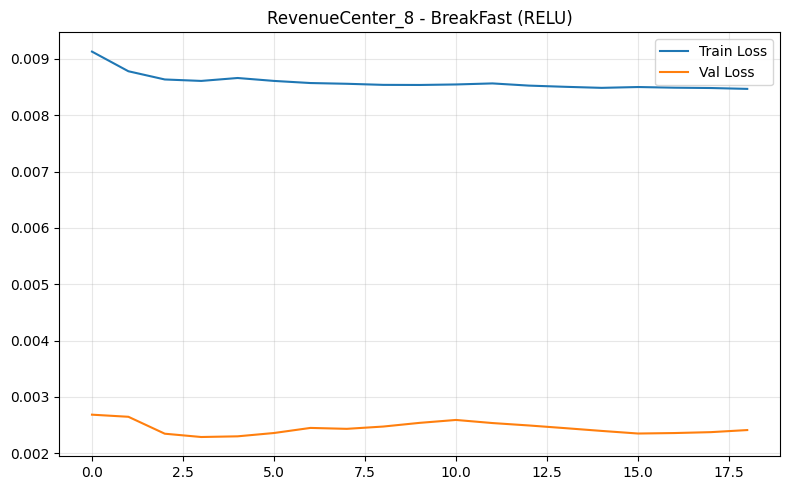

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


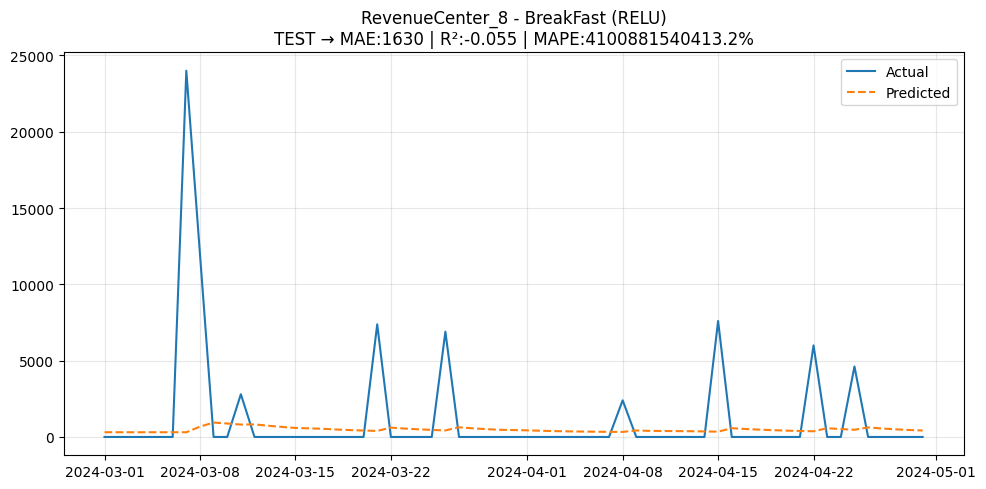

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 305ms/step - loss: 0.0230 - val_loss: 0.1195
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step - loss: 0.0162 - val_loss: 0.0993
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - loss: 0.0168 - val_loss: 0.0998
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - loss: 0.0158 - val_loss: 0.1037
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - loss: 0.0157 - val_loss: 0.1047
Epoch 6/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 176ms/step - loss: 0.0162 - val_loss: 0.1034
Epoch 7/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 169ms/step - loss: 0.0152 - val_loss: 0.1025
Epoch 8/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 194ms/step - loss: 0.0153 - val_loss: 0.1016
Epoch 9/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step - loss: 0.0157 - val_loss: 0.0999
Epoch 10/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 166ms/step - loss: 0.0167 - val_loss: 0.0982
Epoch 11/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 161ms/step - loss: 0.0152 - val_loss: 0.0971
Epoch 12/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 163ms/step - loss: 0.0158 - val_lo

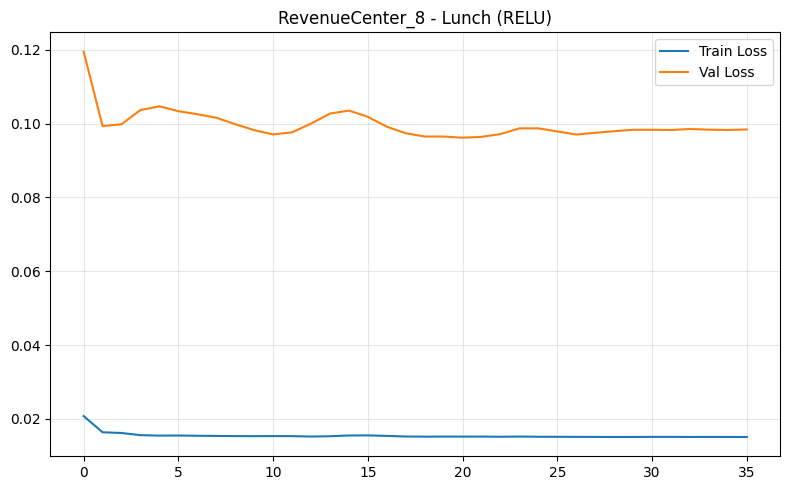

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


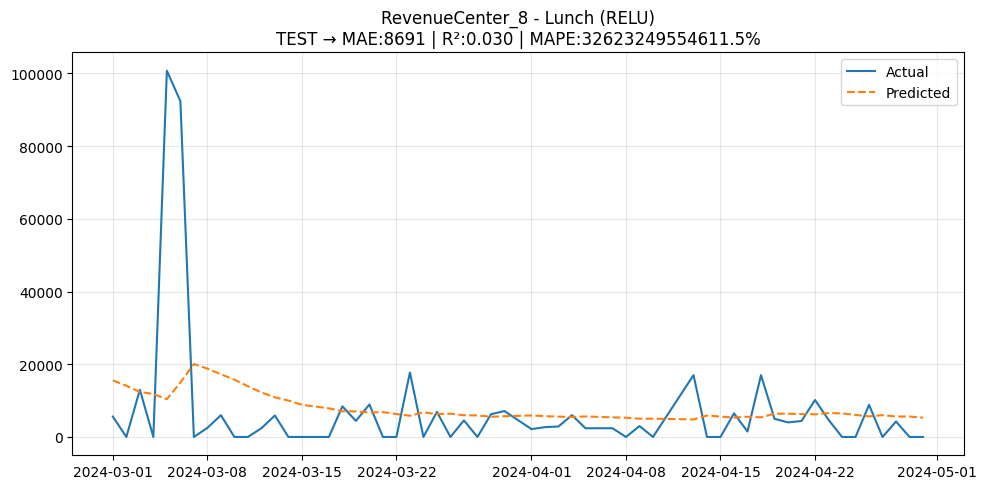

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 300ms/step - loss: 0.0234 - val_loss: 0.0715
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step - loss: 0.0177 - val_loss: 0.0517
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 176ms/step - loss: 0.0150 - val_loss: 0.0523
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step - loss: 0.0129 - val_loss: 0.0573
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 179ms/step - loss: 0.0148 - val_loss: 0.0584
Epoch 6/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 168ms/step - loss: 0.0126 - val_loss: 0.0580
Epoch 7/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 171ms/step - loss: 0.0128 - val_loss: 0.0550
Epoch 8/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 169ms/step - loss: 0.0133 - val_loss: 0.0521
Epoch 9/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step - loss: 0.0149 - val_loss: 0.0518
Epoch 10/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 162ms/step - loss: 0.0134 - val_loss: 0.0541
Epoch 11/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - loss: 0.0130 - val_loss: 0.0565
Epoch 12/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step - loss: 0.0138 - val_lo

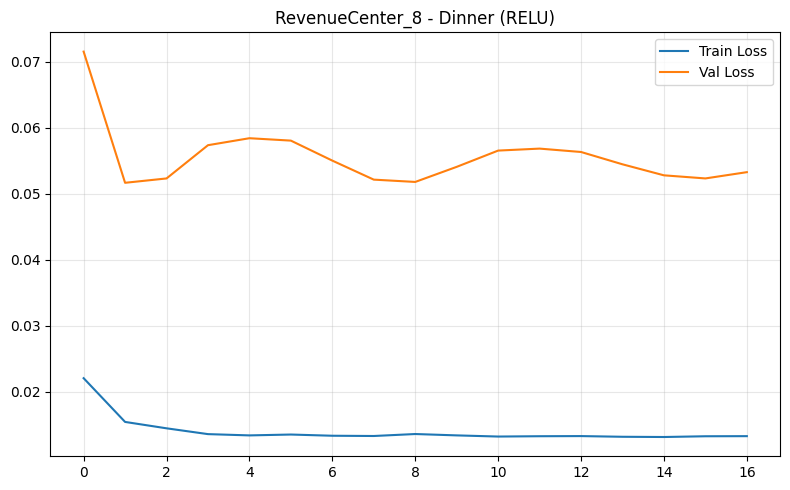

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


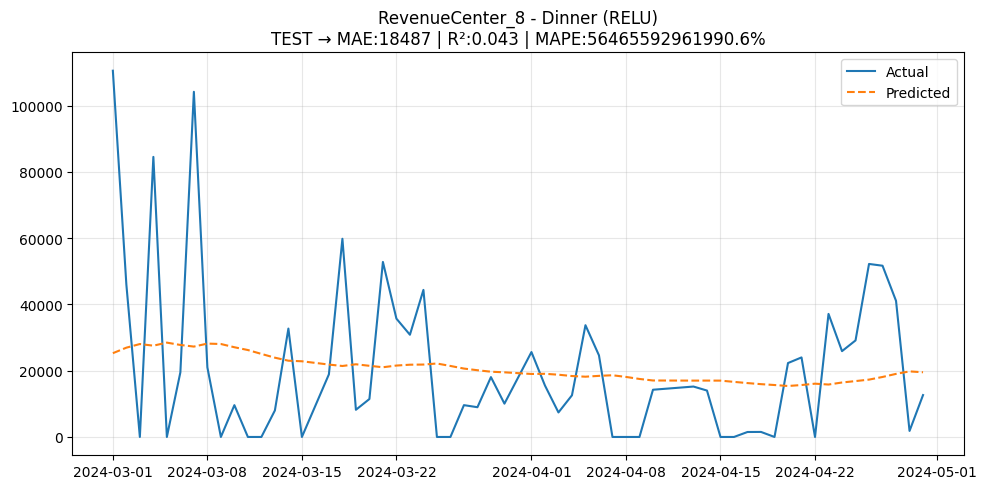

Saved: /content/RevenueCenter_8

Processing: RevenueCenter_7
Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 326ms/step - loss: 0.0112 - val_loss: 0.0048
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 187ms/step - loss: 0.0097 - val_loss: 0.0056
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 189ms/step - loss: 0.0093 - val_loss: 0.0048
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 198ms/step - loss: 0.0100 - val_loss: 0.0046
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 192ms/step - loss: 0.0089 - val_loss: 0.0047
Epoch 6/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 195ms/step - loss: 0.0081 - val_loss: 0.0047
Epoch 7/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 199ms/step - loss: 0.0096 - val_loss: 0.0046
Epoch 8/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 195ms/step - loss: 0.0096 - val_loss: 0.0047
Epoch 9/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 188ms/step - loss: 0.0089 - val_loss: 0.0047
Epoch 10/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 183ms/step - loss: 0.0081 - val_loss: 0.0047
Epoch 11/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 308ms/step - loss: 0.0086 - val_loss: 0.0047
Epoch 12/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 313ms/step - loss: 0.0094 - val_lo

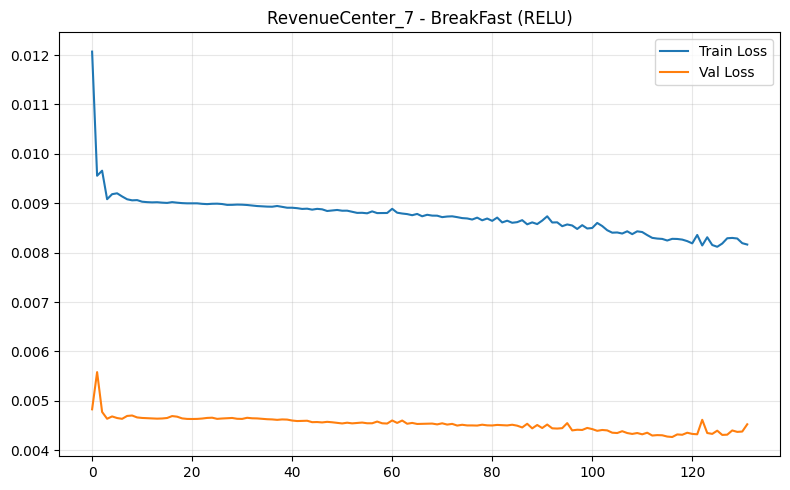

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


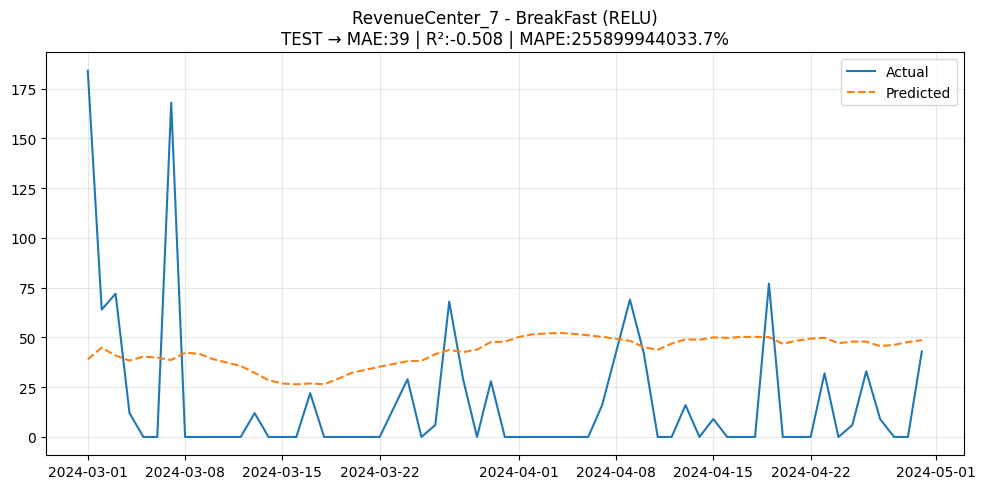

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 323ms/step - loss: 0.0156 - val_loss: 0.0451
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 330ms/step - loss: 0.0101 - val_loss: 0.0393
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 314ms/step - loss: 0.0115 - val_loss: 0.0393
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 294ms/step - loss: 0.0104 - val_loss: 0.0407
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 190ms/step - loss: 0.0100 - val_loss: 0.0416
Epoch 6/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 191ms/step - loss: 0.0120 - val_loss: 0.0414
Epoch 7/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 189ms/step - loss: 0.0120 - val_loss: 0.0406
Epoch 8/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 199ms/step - loss: 0.0106 - val_loss: 0.0398
Epoch 9/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 186ms/step - loss: 0.0111 - val_loss: 0.0394
Epoch 10/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 198ms/step - loss: 0.0090 - val_loss: 0.0395
Epoch 11/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 186ms/step - loss: 0.0098 - val_loss: 0.0395
Epoch 12/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 189ms/step - loss: 0.0114 - val_lo

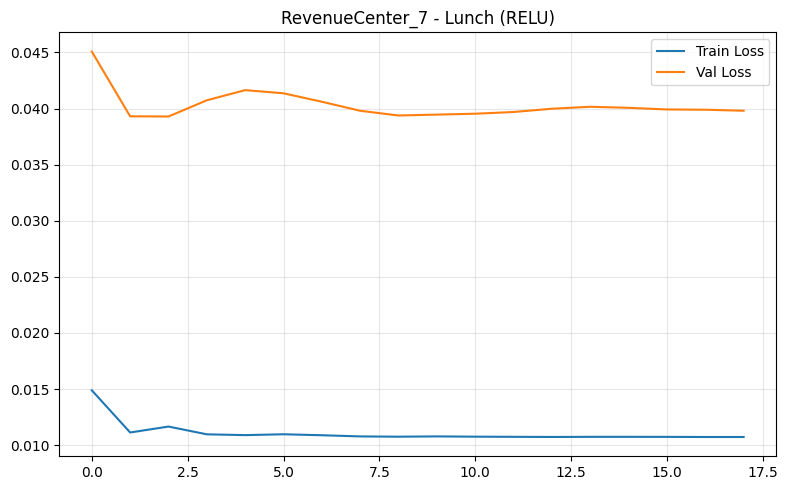

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


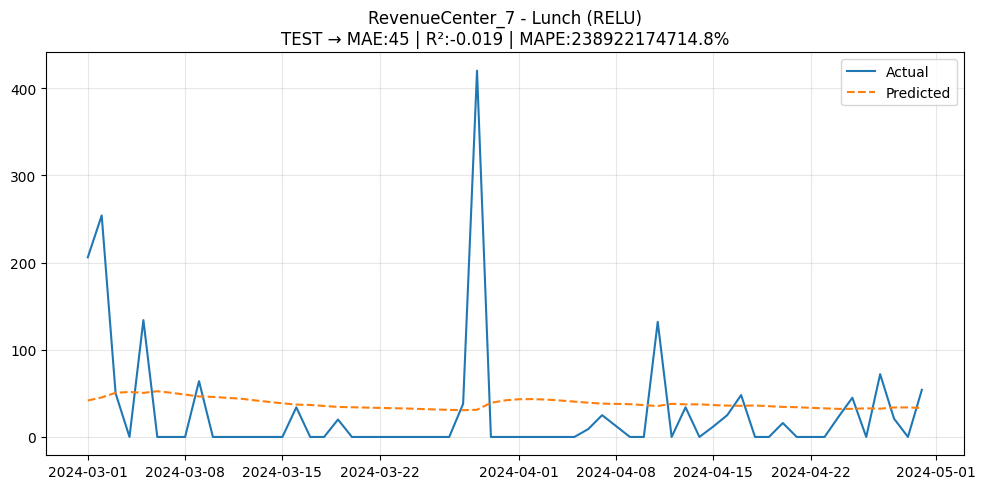

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 321ms/step - loss: 0.0338 - val_loss: 0.1313
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 188ms/step - loss: 0.0246 - val_loss: 0.0909
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 198ms/step - loss: 0.0193 - val_loss: 0.0741
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 193ms/step - loss: 0.0199 - val_loss: 0.0850
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 184ms/step - loss: 0.0168 - val_loss: 0.0938
Epoch 6/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 198ms/step - loss: 0.0188 - val_loss: 0.0941
Epoch 7/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 189ms/step - loss: 0.0213 - val_loss: 0.0905
Epoch 8/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 194ms/step - loss: 0.0201 - val_loss: 0.0858
Epoch 9/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 186ms/step - loss: 0.0177 - val_loss: 0.0816
Epoch 10/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 193ms/step - loss: 0.0182 - val_loss: 0.0791
Epoch 11/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 195ms/step - loss: 0.0189 - val_loss: 0.0791
Epoch 12/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 195ms/step - loss: 0.0182 - val_lo

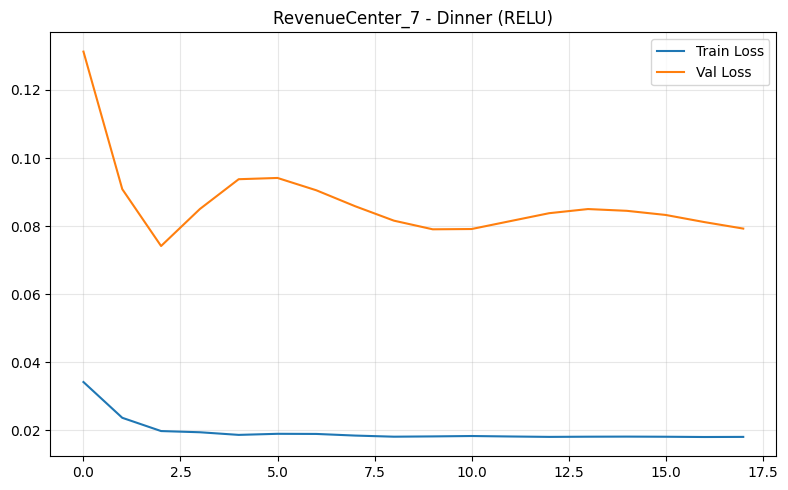

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


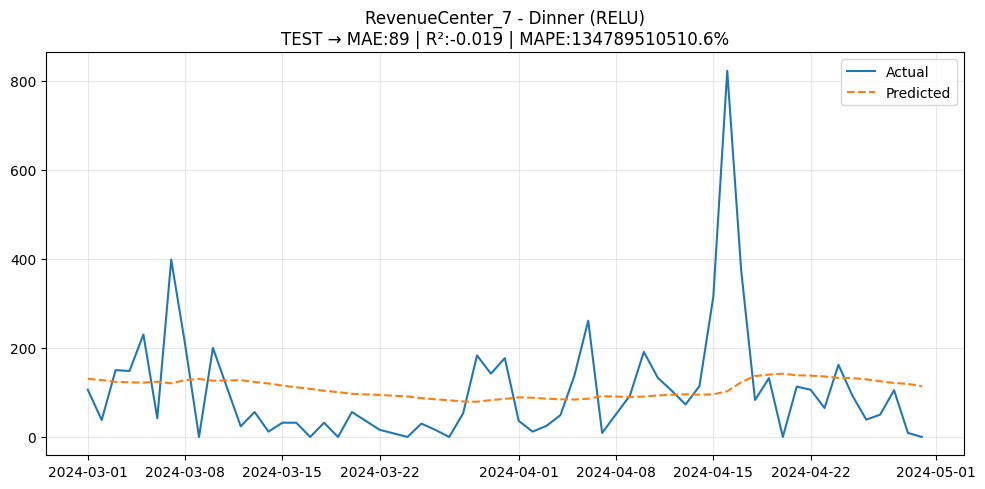

Saved: /content/RevenueCenter_7

Processing: RevenueCenter_6
Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 341ms/step - loss: 0.0358 - val_loss: 0.0538
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 207ms/step - loss: 0.0271 - val_loss: 0.0487
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 199ms/step - loss: 0.0243 - val_loss: 0.0485
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 205ms/step - loss: 0.0243 - val_loss: 0.0492
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 197ms/step - loss: 0.0220 - val_loss: 0.0499
Epoch 6/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 197ms/step - loss: 0.0266 - val_loss: 0.0493
Epoch 7/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 207ms/step - loss: 0.0228 - val_loss: 0.0489
Epoch 8/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 199ms/step - loss: 0.0203 - val_loss: 0.0489
Epoch 9/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 206ms/step - loss: 0.0236 - val_loss: 0.0489
Epoch 10/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 338ms/step - loss: 0.0256 - val_loss: 0.0491
Epoch 11/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 340ms/step - loss: 0.0215 - val_loss: 0.0493
Epoch 12/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 227ms/step - loss: 0.0222 - val_lo

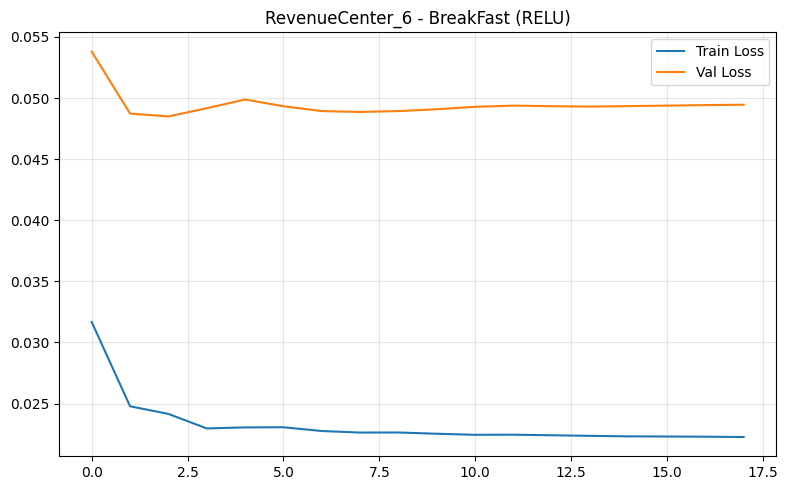

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


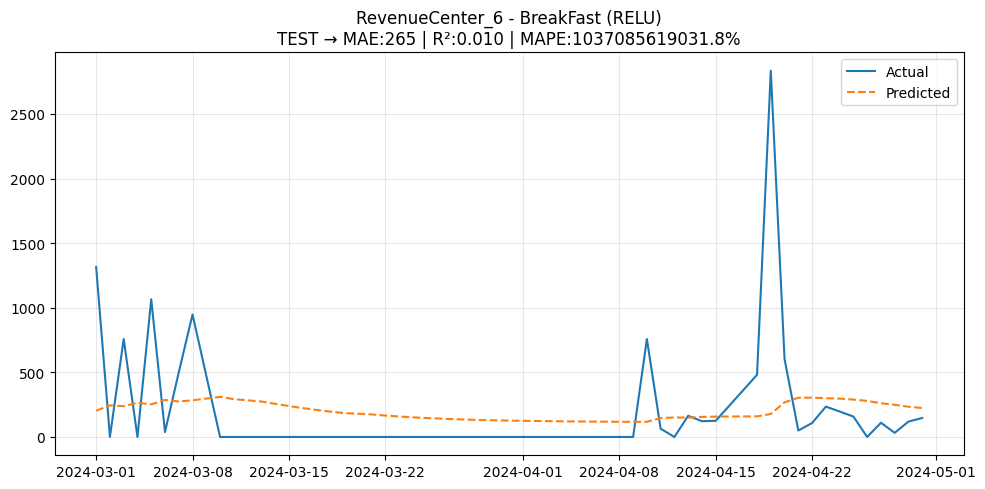

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 355ms/step - loss: 0.0193 - val_loss: 0.0314
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 330ms/step - loss: 0.0133 - val_loss: 0.0176
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 352ms/step - loss: 0.0131 - val_loss: 0.0179
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 237ms/step - loss: 0.0118 - val_loss: 0.0210
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 203ms/step - loss: 0.0092 - val_loss: 0.0229
Epoch 6/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 205ms/step - loss: 0.0100 - val_loss: 0.0220
Epoch 7/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 211ms/step - loss: 0.0112 - val_loss: 0.0200
Epoch 8/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 213ms/step - loss: 0.0116 - val_loss: 0.0186
Epoch 9/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 209ms/step - loss: 0.0122 - val_loss: 0.0183
Epoch 10/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 200ms/step - loss: 0.0095 - val_loss: 0.0188
Epoch 11/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 201ms/step - loss: 0.0093 - val_loss: 0.0194
Epoch 12/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 214ms/step - loss: 0.0116 - val_lo

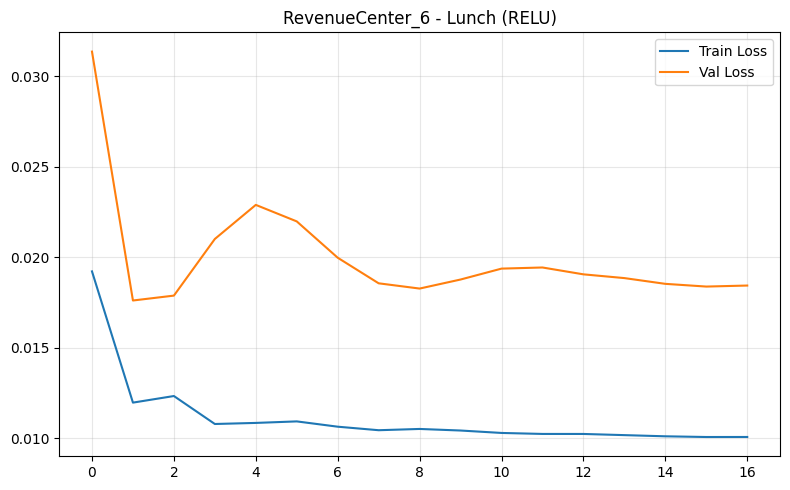

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


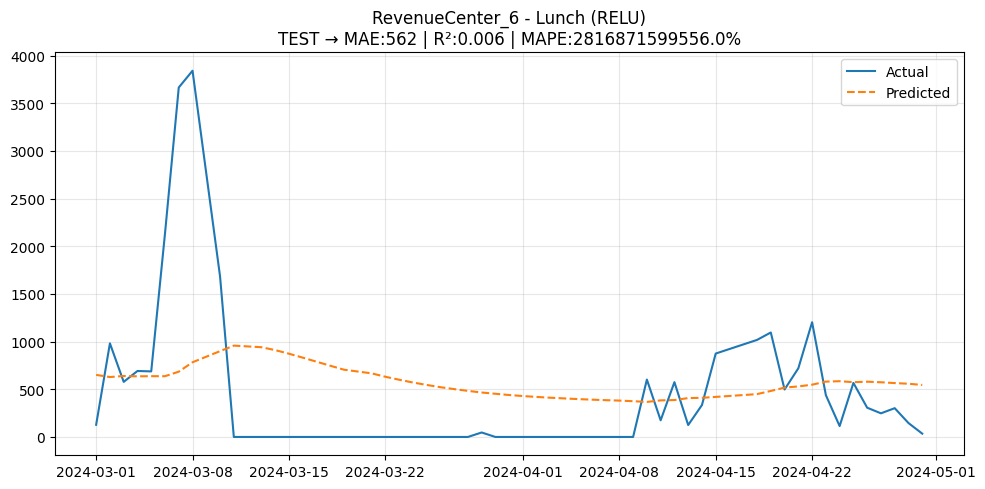

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 334ms/step - loss: 0.0034 - val_loss: 0.0247
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 215ms/step - loss: 0.0029 - val_loss: 0.0248
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 204ms/step - loss: 0.0034 - val_loss: 0.0251
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 205ms/step - loss: 0.0037 - val_loss: 0.0250
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 226ms/step - loss: 0.0030 - val_loss: 0.0248
Epoch 6/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 211ms/step - loss: 0.0034 - val_loss: 0.0248
Epoch 7/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 215ms/step - loss: 0.0036 - val_loss: 0.0248
Epoch 8/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 206ms/step - loss: 0.0034 - val_loss: 0.0249
Epoch 9/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 202ms/step - loss: 0.0022 - val_loss: 0.0249
Epoch 10/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 214ms/step - loss: 0.0032 - val_loss: 0.0248
Epoch 11/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 210ms/step - loss: 0.0028 - val_loss: 0.0247
Epoch 12/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 287ms/step - loss: 0.0018 - val_lo

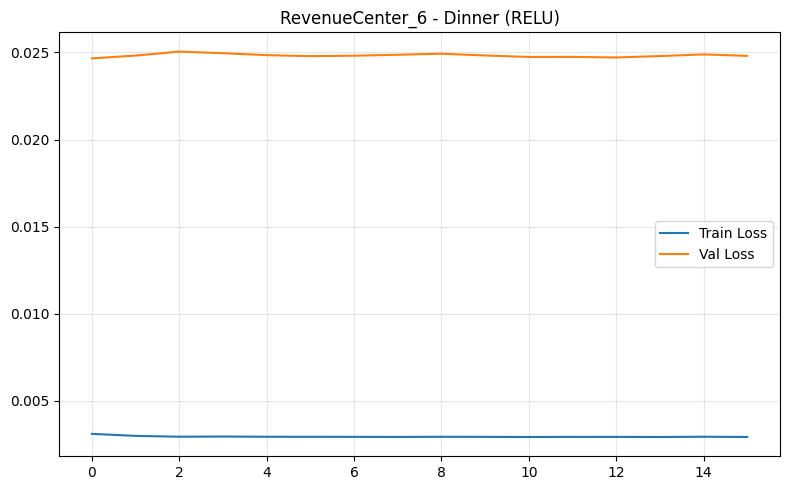

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


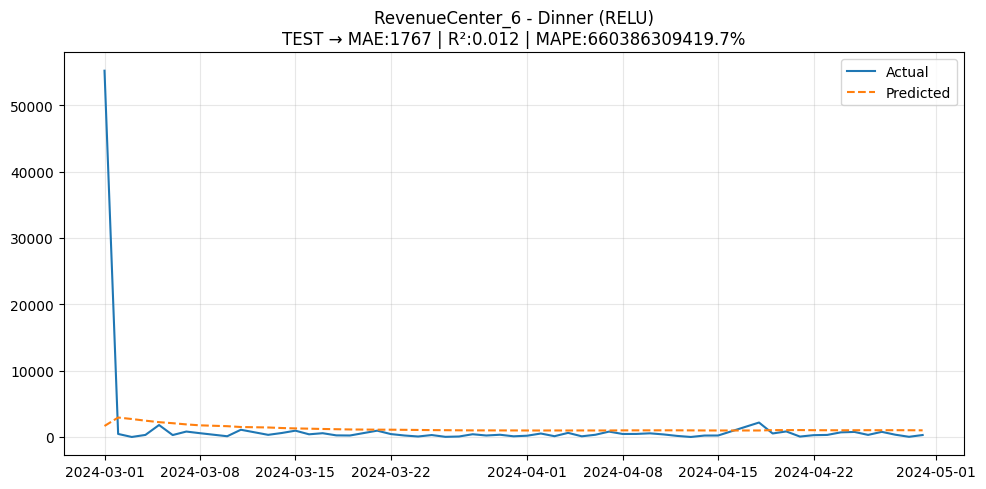

Saved: /content/RevenueCenter_6

Processing: RevenueCenter_5
Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 345ms/step - loss: 0.1283 - val_loss: 0.3108
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 211ms/step - loss: 0.0572 - val_loss: 0.0417
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 214ms/step - loss: 0.0166 - val_loss: 0.0343
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 204ms/step - loss: 0.0164 - val_loss: 0.0357
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 211ms/step - loss: 0.0119 - val_loss: 0.0647
Epoch 6/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 211ms/step - loss: 0.0128 - val_loss: 0.0513
Epoch 7/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 209ms/step - loss: 0.0111 - val_loss: 0.0225
Epoch 8/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 367ms/step - loss: 0.0095 - val_loss: 0.0131
Epoch 9/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 350ms/step - loss: 0.0096 - val_loss: 0.0146
Epoch 10/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 307ms/step - loss: 0.0092 - val_loss: 0.0250
Epoch 11/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 218ms/step - loss: 0.0093 - val_loss: 0.0313
Epoch 12/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 220ms/step - loss: 0.0096 - val_lo

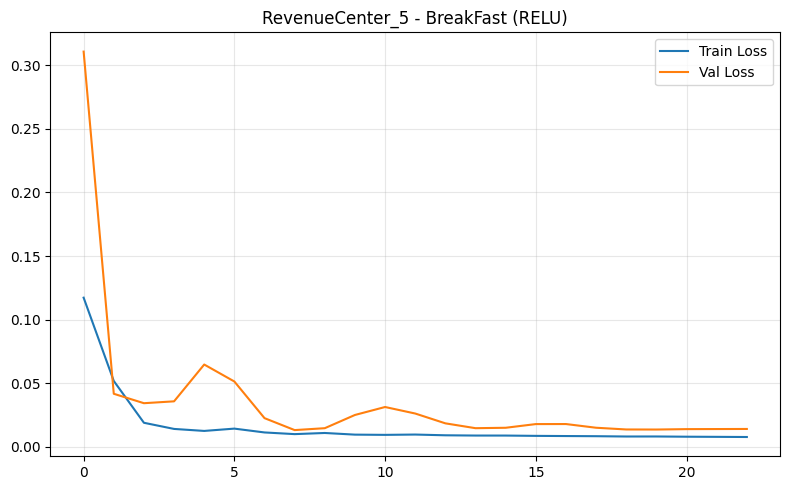

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


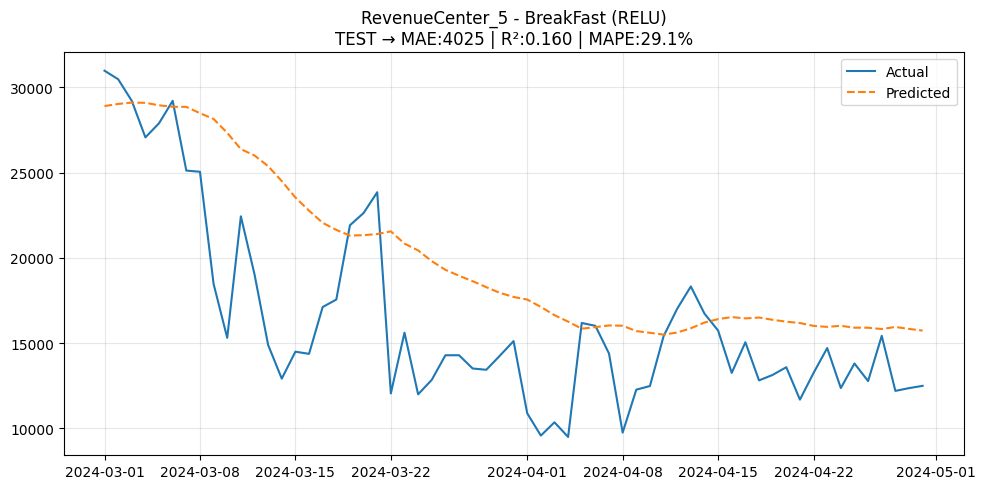

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 345ms/step - loss: 0.0216 - val_loss: 0.0237
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 217ms/step - loss: 0.0162 - val_loss: 0.0166
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 211ms/step - loss: 0.0131 - val_loss: 0.0162
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 218ms/step - loss: 0.0170 - val_loss: 0.0170
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 232ms/step - loss: 0.0123 - val_loss: 0.0184
Epoch 6/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 218ms/step - loss: 0.0189 - val_loss: 0.0181
Epoch 7/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 210ms/step - loss: 0.0153 - val_loss: 0.0176
Epoch 8/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 215ms/step - loss: 0.0136 - val_loss: 0.0171
Epoch 9/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 219ms/step - loss: 0.0138 - val_loss: 0.0167
Epoch 10/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 371ms/step - loss: 0.0159 - val_loss: 0.0166
Epoch 11/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 331ms/step - loss: 0.0128 - val_loss: 0.0171
Epoch 12/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 266ms/step - loss: 0.0161 - val_lo

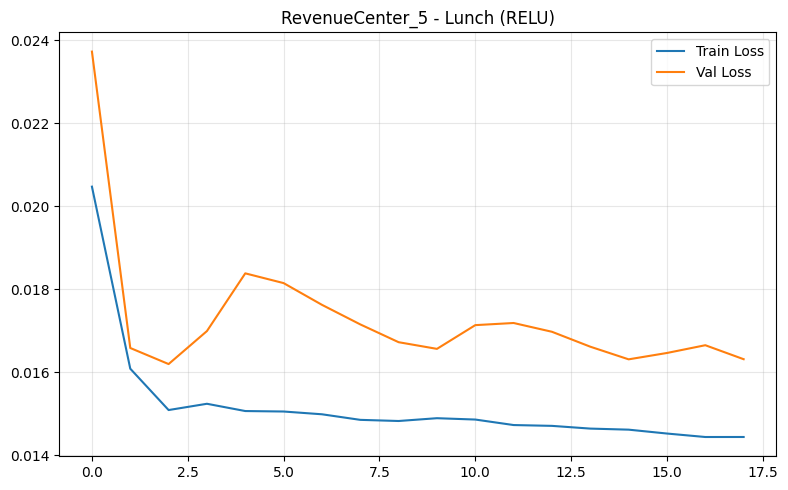

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


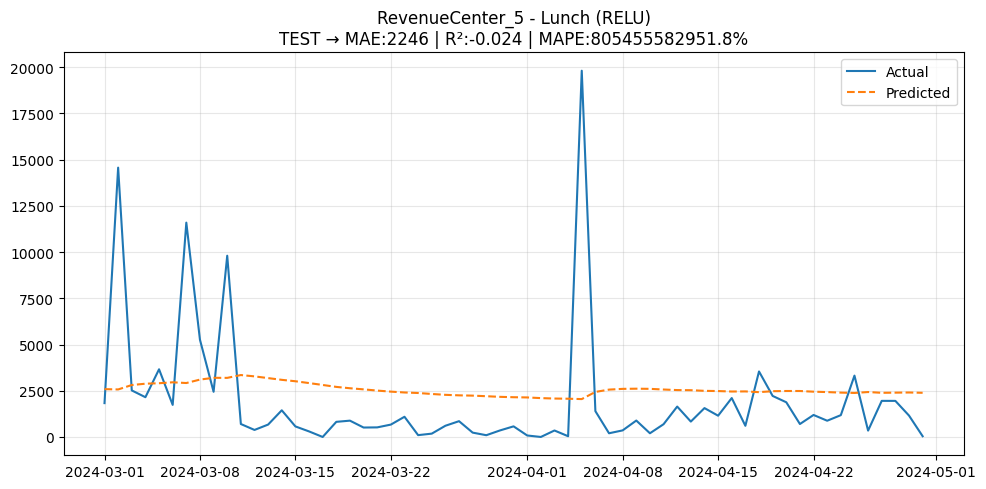

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 340ms/step - loss: 0.0376 - val_loss: 0.0699
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 217ms/step - loss: 0.0232 - val_loss: 0.0521
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 408ms/step - loss: 0.0239 - val_loss: 0.0528
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 352ms/step - loss: 0.0201 - val_loss: 0.0574
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 223ms/step - loss: 0.0192 - val_loss: 0.0587
Epoch 6/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 216ms/step - loss: 0.0257 - val_loss: 0.0564
Epoch 7/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 231ms/step - loss: 0.0212 - val_loss: 0.0543
Epoch 8/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 221ms/step - loss: 0.0223 - val_loss: 0.0533
Epoch 9/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 207ms/step - loss: 0.0193 - val_loss: 0.0536
Epoch 10/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 218ms/step - loss: 0.0214 - val_loss: 0.0541
Epoch 11/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 203ms/step - loss: 0.0214 - val_loss: 0.0548
Epoch 12/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 220ms/step - loss: 0.0222 - val_lo

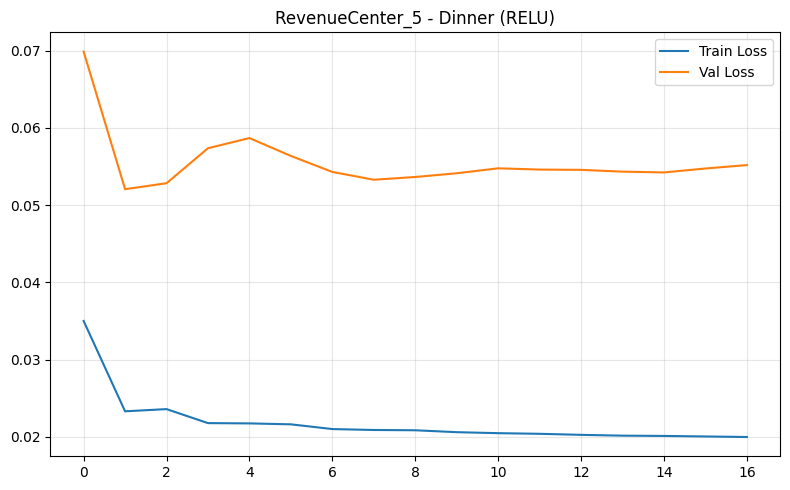

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


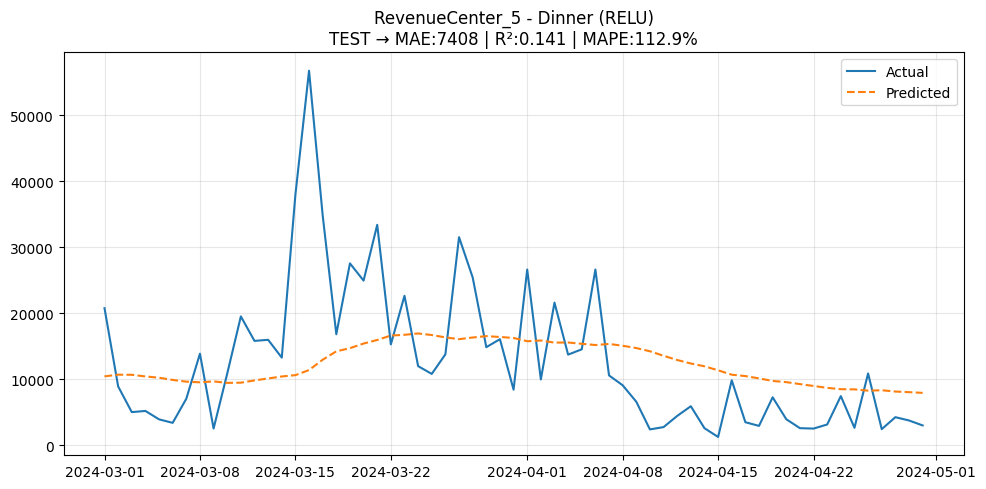

Saved: /content/RevenueCenter_5

Processing: RevenueCenter_3
Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 341ms/step - loss: 0.0403 - val_loss: 0.0609
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 215ms/step - loss: 0.0315 - val_loss: 0.0403
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 204ms/step - loss: 0.0232 - val_loss: 0.0367
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 217ms/step - loss: 0.0255 - val_loss: 0.0373
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 211ms/step - loss: 0.0215 - val_loss: 0.0407
Epoch 6/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 213ms/step - loss: 0.0217 - val_loss: 0.0417
Epoch 7/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 210ms/step - loss: 0.0247 - val_loss: 0.0408
Epoch 8/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 216ms/step - loss: 0.0236 - val_loss: 0.0391
Epoch 9/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 210ms/step - loss: 0.0236 - val_loss: 0.0377
Epoch 10/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 209ms/step - loss: 0.0236 - val_loss: 0.0371
Epoch 11/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 206ms/step - loss: 0.0217 - val_loss: 0.0373
Epoch 12/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 297ms/step - loss: 0.0221 - val_lo

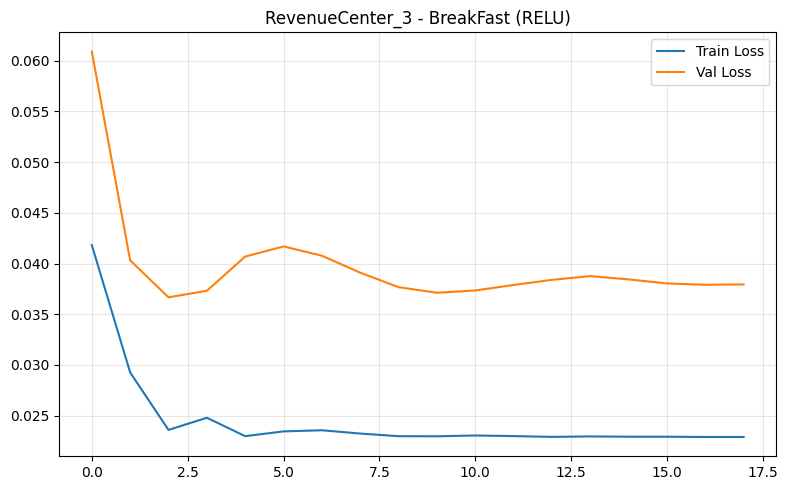

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


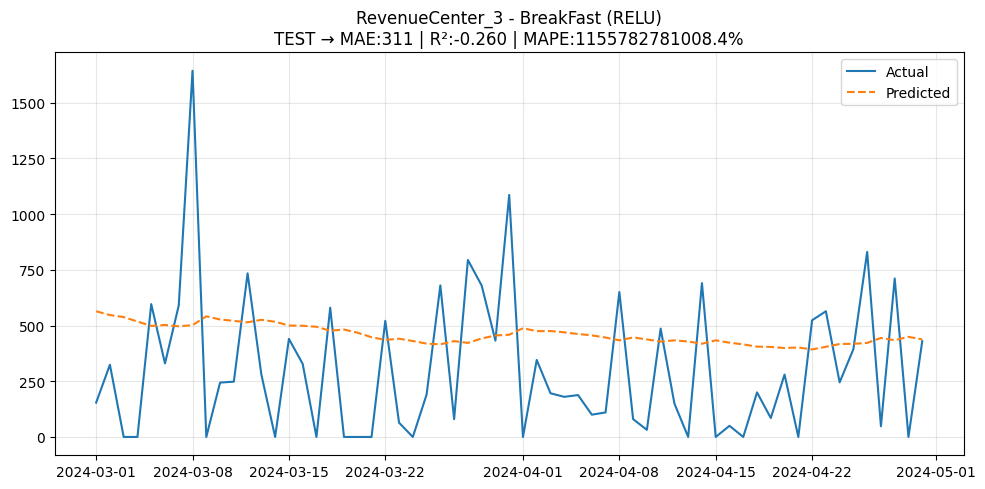

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 346ms/step - loss: 0.0320 - val_loss: 0.1000
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 215ms/step - loss: 0.0191 - val_loss: 0.0571
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 218ms/step - loss: 0.0096 - val_loss: 0.0427
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 218ms/step - loss: 0.0117 - val_loss: 0.0513
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 415ms/step - loss: 0.0091 - val_loss: 0.0607
Epoch 6/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 354ms/step - loss: 0.0093 - val_loss: 0.0621
Epoch 7/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 269ms/step - loss: 0.0113 - val_loss: 0.0585
Epoch 8/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 212ms/step - loss: 0.0096 - val_loss: 0.0538
Epoch 9/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 212ms/step - loss: 0.0104 - val_loss: 0.0505
Epoch 10/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 221ms/step - loss: 0.0098 - val_loss: 0.0508
Epoch 11/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 247ms/step - loss: 0.0102 - val_loss: 0.0533
Epoch 12/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 217ms/step - loss: 0.0089 - val_lo

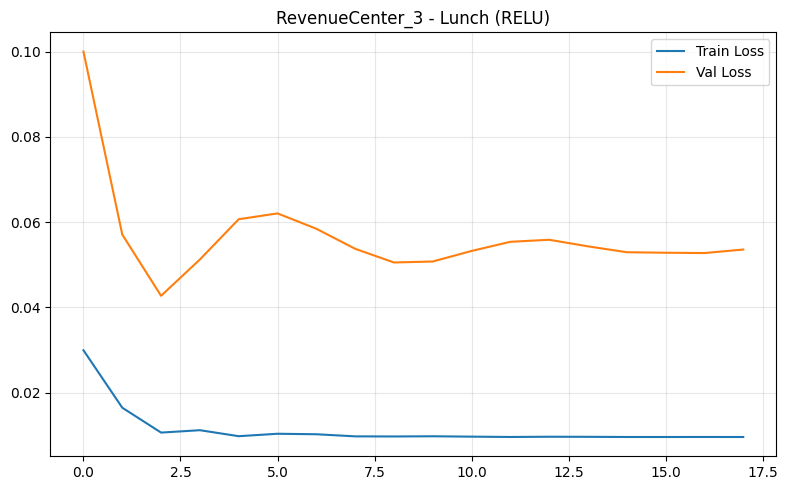

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


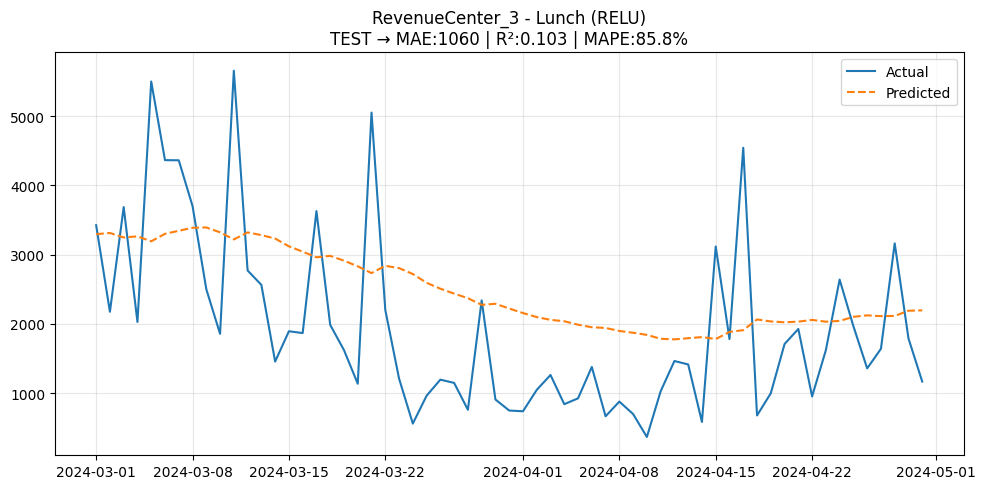

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 339ms/step - loss: 0.0666 - val_loss: 0.3146
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 232ms/step - loss: 0.0356 - val_loss: 0.1354
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 219ms/step - loss: 0.0156 - val_loss: 0.0275
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 216ms/step - loss: 0.0175 - val_loss: 0.0820
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 219ms/step - loss: 0.0126 - val_loss: 0.1193
Epoch 6/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 241ms/step - loss: 0.0134 - val_loss: 0.1149
Epoch 7/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 213ms/step - loss: 0.0129 - val_loss: 0.0915
Epoch 8/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 217ms/step - loss: 0.0109 - val_loss: 0.0659
Epoch 9/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 220ms/step - loss: 0.0120 - val_loss: 0.0532
Epoch 10/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 210ms/step - loss: 0.0116 - val_loss: 0.0599
Epoch 11/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 207ms/step - loss: 0.0117 - val_loss: 0.0743
Epoch 12/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 383ms/step - loss: 0.0103 - val_lo

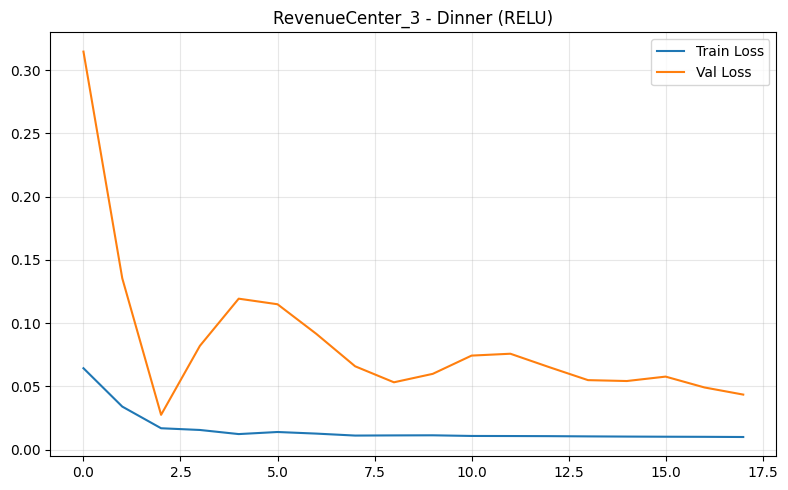

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


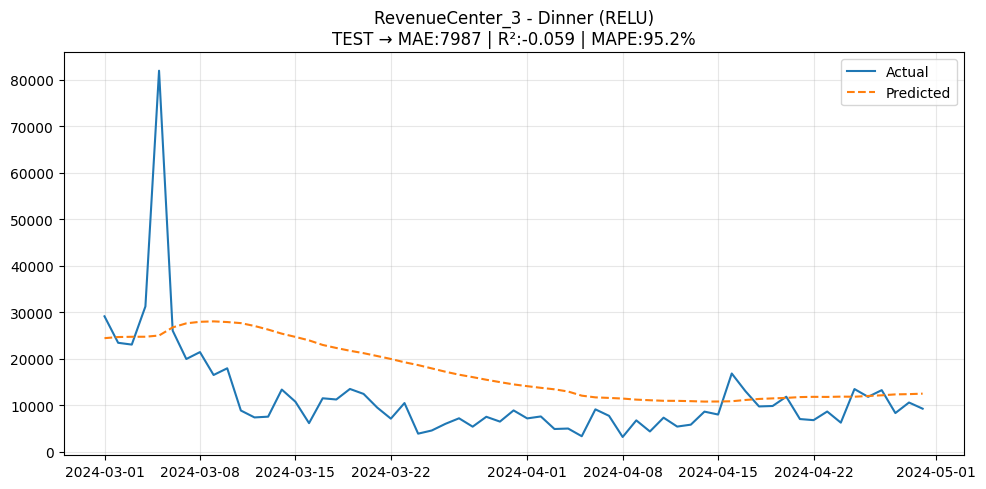

Saved: /content/RevenueCenter_3

Processing: RevenueCenter_4
Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 339ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 218ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 206ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 317ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 395ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 6/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 348ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 7/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 216ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 8/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 212ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 9/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 213ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 10/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 217ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 11/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 205ms/step - loss: 0.0000e+00 - val_loss

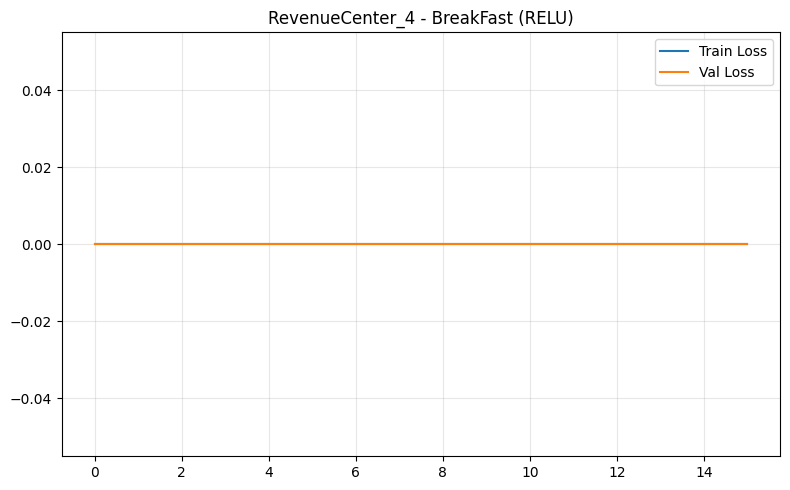

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


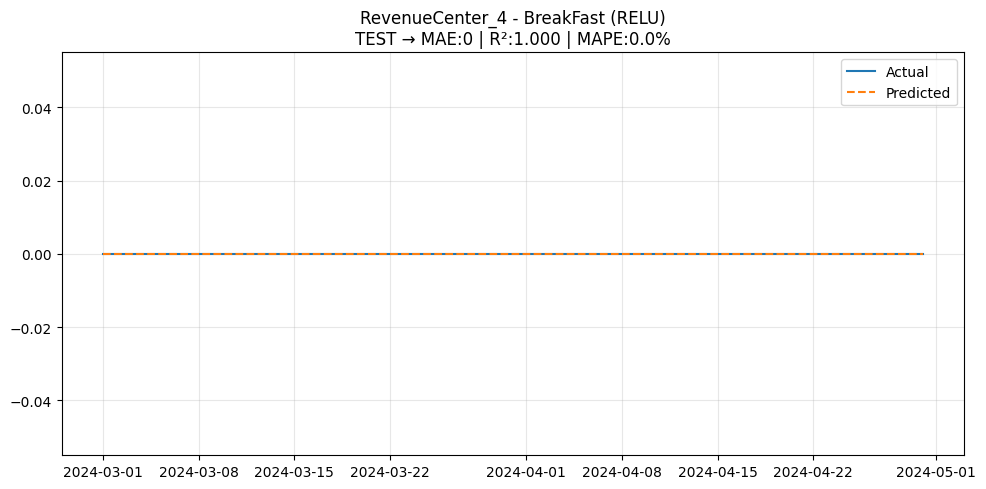

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 509ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 211ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 204ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 218ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 207ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 6/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 204ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 7/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 216ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 8/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 222ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 9/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 203ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 10/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 219ms/step - loss: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 11/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 215ms/step - loss: 0.0000e+00 - val_loss

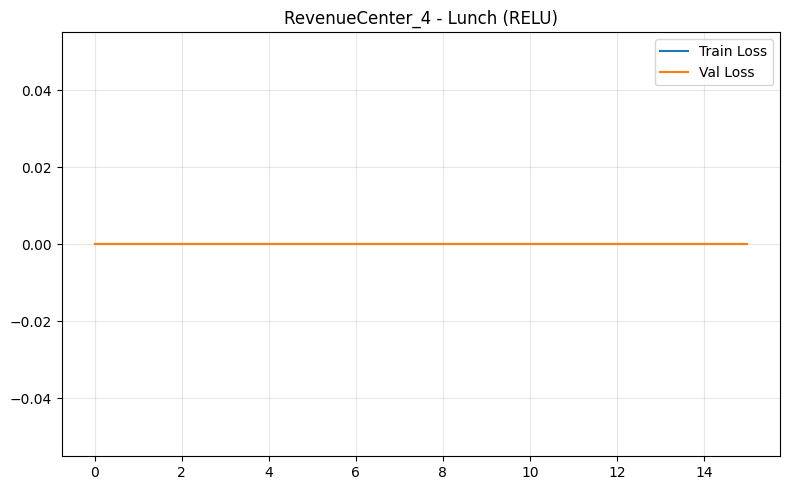

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


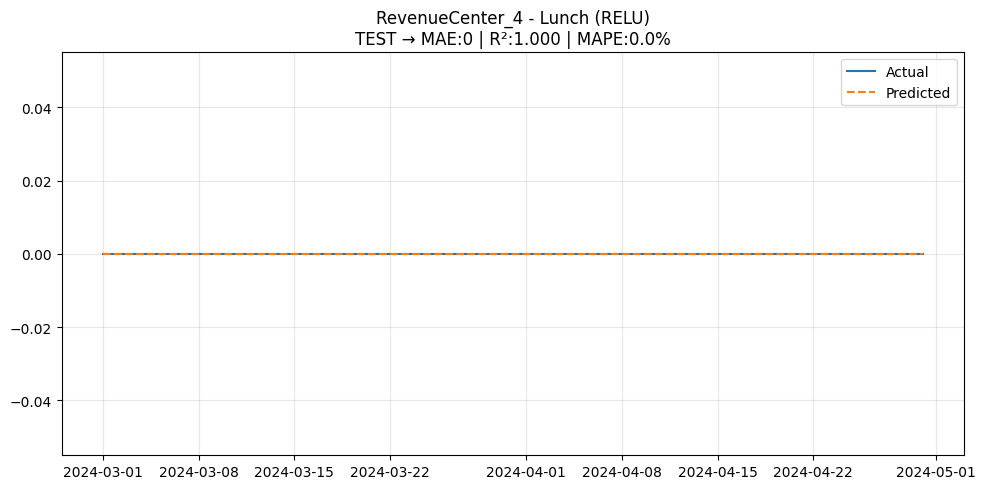

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 346ms/step - loss: 0.0014 - val_loss: 3.0152e-07
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 218ms/step - loss: 0.0044 - val_loss: 1.2140e-05
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 217ms/step - loss: 0.0044 - val_loss: 1.7994e-05
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 224ms/step - loss: 0.0014 - val_loss: 8.7996e-06
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 215ms/step - loss: 0.0024 - val_loss: 5.8790e-06
Epoch 6/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 394ms/step - loss: 0.0044 - val_loss: 4.7853e-06
Epoch 7/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 383ms/step - loss: 0.0024 - val_loss: 3.2991e-06
Epoch 8/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 219ms/step - loss: 0.0024 - val_loss: 6.9830e-06
Epoch 9/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 230ms/step - loss: 0.0044 - val_loss: 1.4000e-05
Epoch 10/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 206ms/step - loss: 0.0043 - val_loss: 1.3249e-05
Epoch 11/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 223ms/step - loss: 0.0024 - val_loss: 6.2214e-06
Epoch 12/300
3/3 ━━━━━━━━━━━━━━

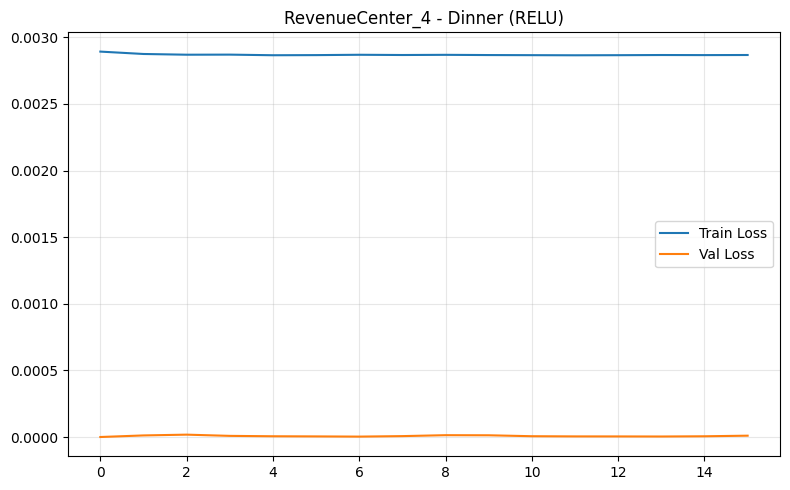

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


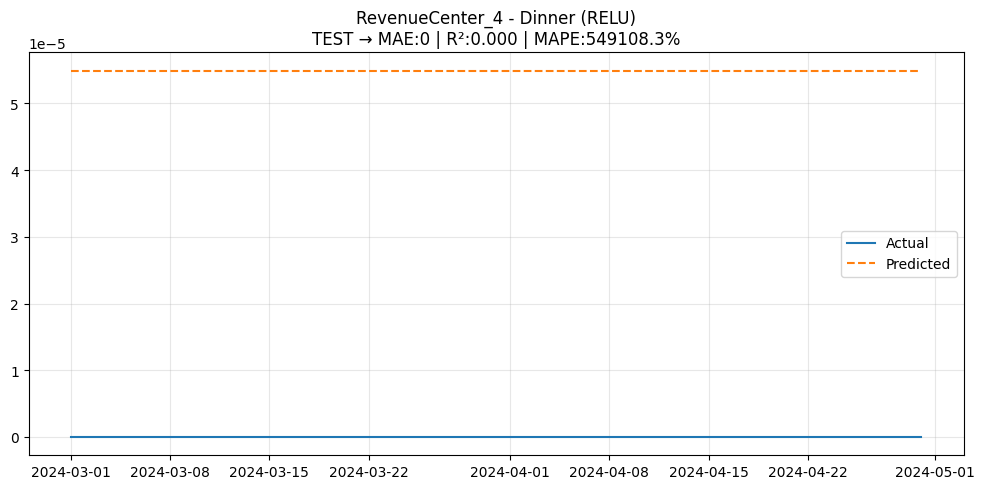

Saved: /content/RevenueCenter_4

Processing: RevenueCenter_9
Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 463ms/step - loss: 0.0155 - val_loss: 0.0996
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 329ms/step - loss: 0.0093 - val_loss: 0.0671
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 310ms/step - loss: 0.0095 - val_loss: 0.0763
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 189ms/step - loss: 0.0085 - val_loss: 0.0849
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 191ms/step - loss: 0.0090 - val_loss: 0.0855
Epoch 6/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 200ms/step - loss: 0.0088 - val_loss: 0.0805
Epoch 7/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 192ms/step - loss: 0.0093 - val_loss: 0.0740
Epoch 8/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 211ms/step - loss: 0.0087 - val_loss: 0.0700
Epoch 9/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 189ms/step - loss: 0.0082 - val_loss: 0.0702
Epoch 10/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 201ms/step - loss: 0.0098 - val_loss: 0.0713
Epoch 11/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 192ms/step - loss: 0.0080 - val_loss: 0.0734
Epoch 12/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 190ms/step - loss: 0.0075 - val_lo

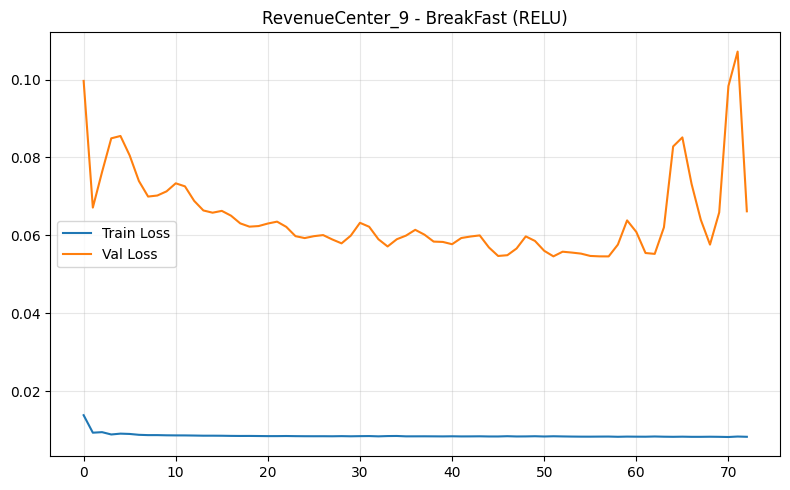

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


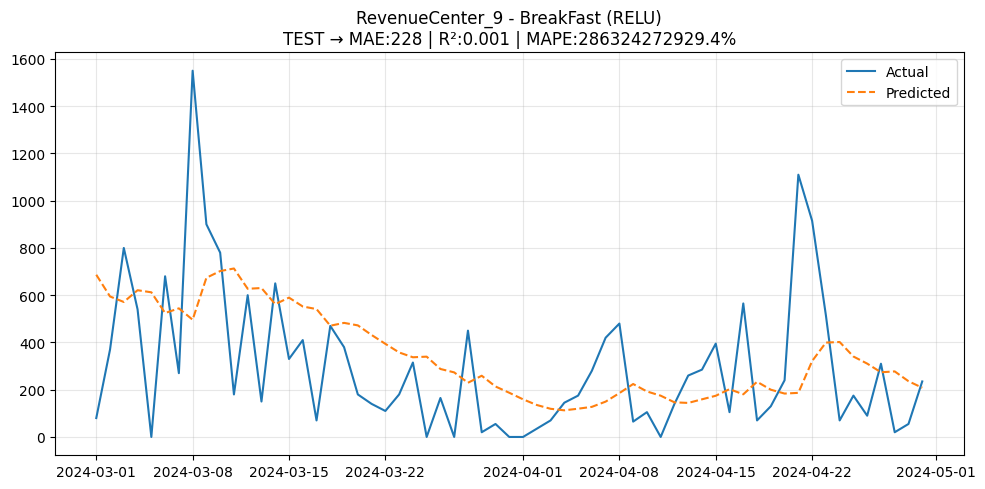

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 325ms/step - loss: 0.0557 - val_loss: 0.0660
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 199ms/step - loss: 0.0363 - val_loss: 0.0460
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 199ms/step - loss: 0.0324 - val_loss: 0.0462
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 204ms/step - loss: 0.0321 - val_loss: 0.0469
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 191ms/step - loss: 0.0303 - val_loss: 0.0501
Epoch 6/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 206ms/step - loss: 0.0328 - val_loss: 0.0503
Epoch 7/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 196ms/step - loss: 0.0321 - val_loss: 0.0486
Epoch 8/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 199ms/step - loss: 0.0317 - val_loss: 0.0467
Epoch 9/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 196ms/step - loss: 0.0325 - val_loss: 0.0455
Epoch 10/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 192ms/step - loss: 0.0315 - val_loss: 0.0454
Epoch 11/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 198ms/step - loss: 0.0292 - val_loss: 0.0454
Epoch 12/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 209ms/step - loss: 0.0296 - val_lo

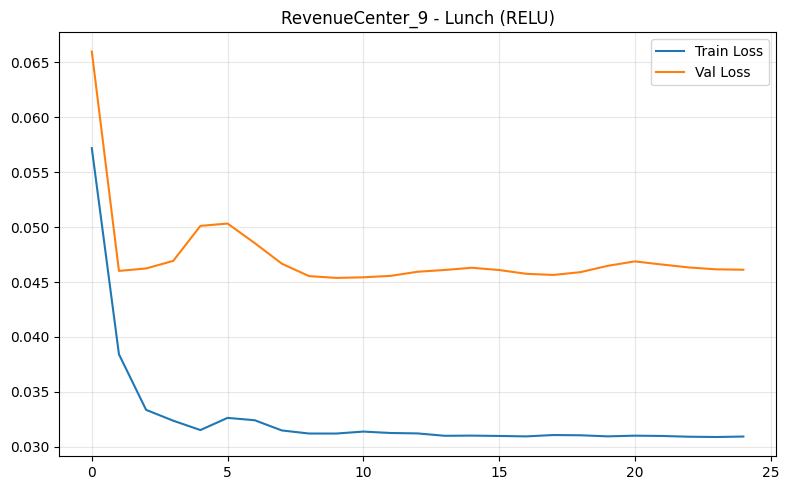

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


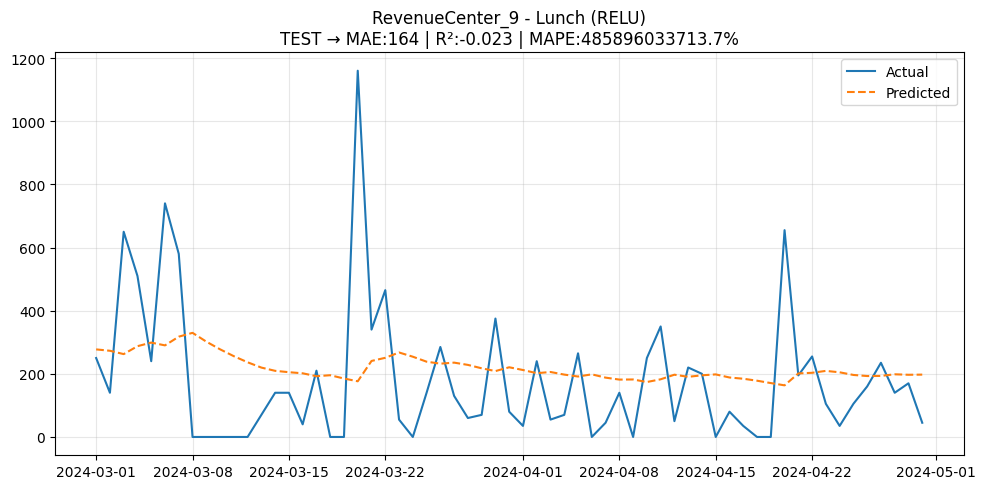

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 324ms/step - loss: 0.0261 - val_loss: 0.0131
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 298ms/step - loss: 0.0185 - val_loss: 0.0160
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 320ms/step - loss: 0.0250 - val_loss: 0.0161
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 333ms/step - loss: 0.0219 - val_loss: 0.0139
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 202ms/step - loss: 0.0225 - val_loss: 0.0135
Epoch 6/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 203ms/step - loss: 0.0233 - val_loss: 0.0134
Epoch 7/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 189ms/step - loss: 0.0239 - val_loss: 0.0135
Epoch 8/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 190ms/step - loss: 0.0230 - val_loss: 0.0136
Epoch 9/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 202ms/step - loss: 0.0195 - val_loss: 0.0139
Epoch 10/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 191ms/step - loss: 0.0203 - val_loss: 0.0144
Epoch 11/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 203ms/step - loss: 0.0241 - val_loss: 0.0147
Epoch 12/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 190ms/step - loss: 0.0240 - val_lo

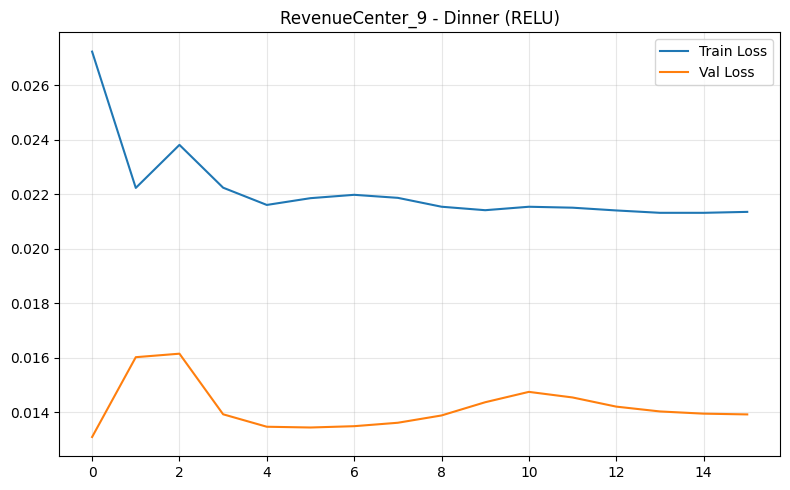

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


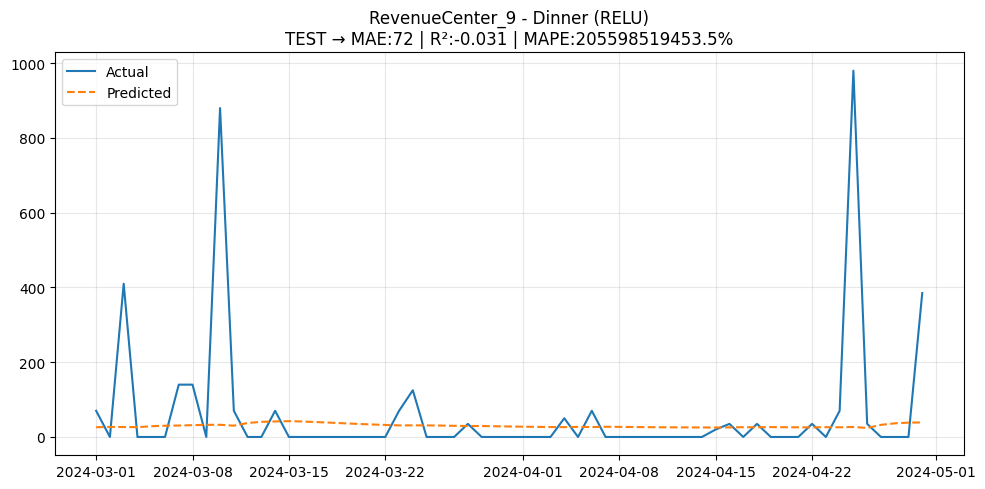

Saved: /content/RevenueCenter_9

Processing: RevenueCenter_1
Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 414ms/step - loss: 0.0125 - val_loss: 0.0592
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 225ms/step - loss: 0.0078 - val_loss: 0.0305
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 221ms/step - loss: 0.0060 - val_loss: 0.0347
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 219ms/step - loss: 0.0046 - val_loss: 0.0424
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 224ms/step - loss: 0.0062 - val_loss: 0.0434
Epoch 6/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 222ms/step - loss: 0.0049 - val_loss: 0.0409
Epoch 7/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 223ms/step - loss: 0.0050 - val_loss: 0.0366
Epoch 8/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 220ms/step - loss: 0.0050 - val_loss: 0.0337
Epoch 9/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 219ms/step - loss: 0.0059 - val_loss: 0.0334
Epoch 10/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 236ms/step - loss: 0.0051 - val_loss: 0.0348
Epoch 11/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 212ms/step - loss: 0.0050 - val_loss: 0.0354
Epoch 12/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 218ms/step - loss: 0.0056 - val_lo

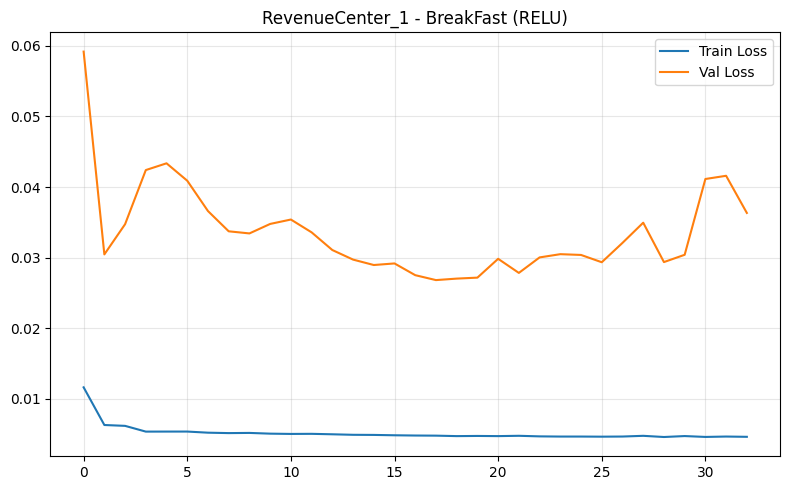

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


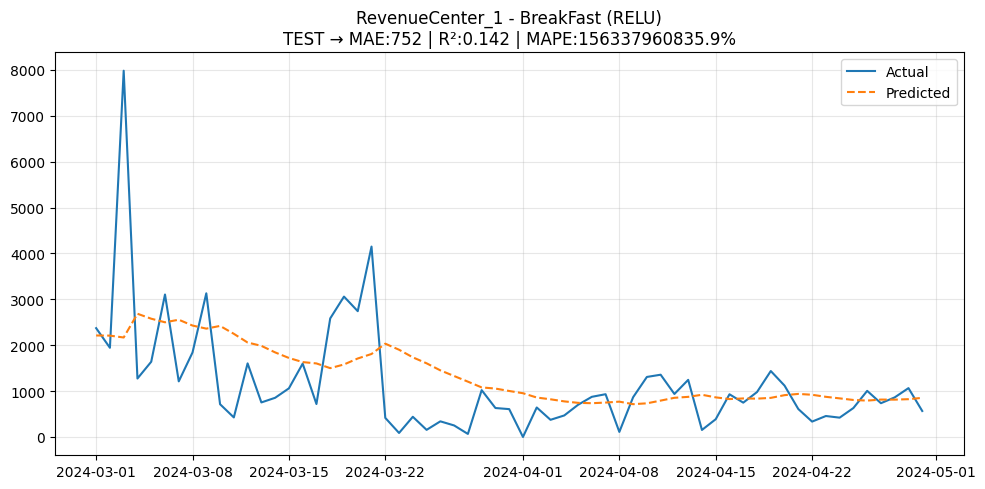

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 347ms/step - loss: 0.0328 - val_loss: 0.1414
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 242ms/step - loss: 0.0165 - val_loss: 0.0722
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 216ms/step - loss: 0.0144 - val_loss: 0.0596
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 223ms/step - loss: 0.0136 - val_loss: 0.0774
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 229ms/step - loss: 0.0139 - val_loss: 0.0862
Epoch 6/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 218ms/step - loss: 0.0140 - val_loss: 0.0855
Epoch 7/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 215ms/step - loss: 0.0113 - val_loss: 0.0804
Epoch 8/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 251ms/step - loss: 0.0124 - val_loss: 0.0738
Epoch 9/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 384ms/step - loss: 0.0107 - val_loss: 0.0694
Epoch 10/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 387ms/step - loss: 0.0116 - val_loss: 0.0683
Epoch 11/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 235ms/step - loss: 0.0102 - val_loss: 0.0710
Epoch 12/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 232ms/step - loss: 0.0110 - val_lo

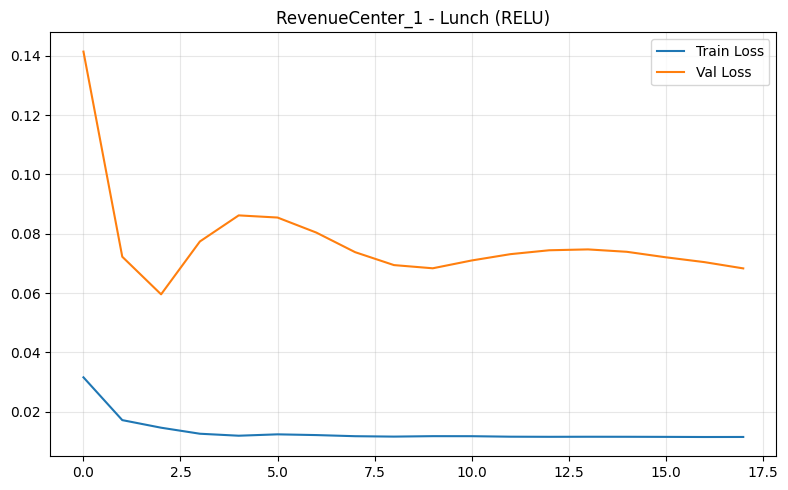

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


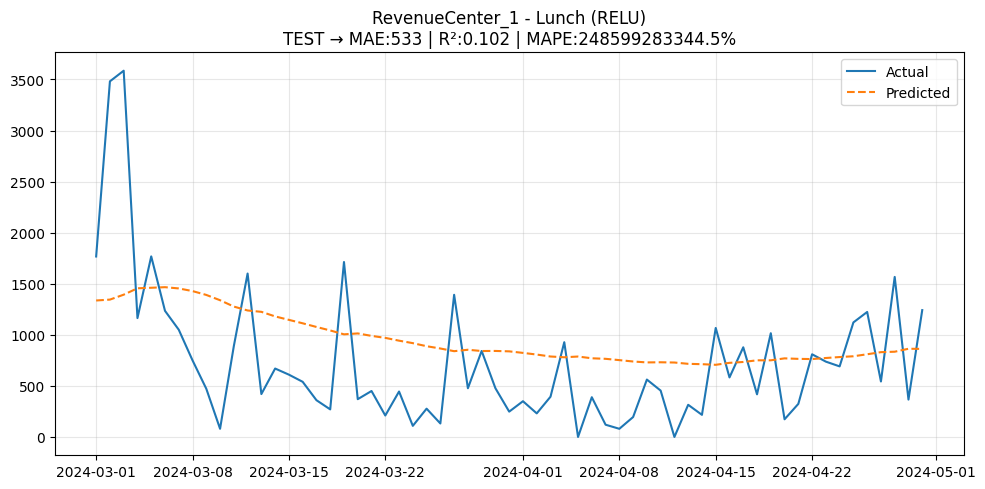

Epoch 1/300


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 536ms/step - loss: 0.0559 - val_loss: 0.1724
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 238ms/step - loss: 0.0373 - val_loss: 0.0796
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 224ms/step - loss: 0.0195 - val_loss: 0.0236
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 221ms/step - loss: 0.0196 - val_loss: 0.0336
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 233ms/step - loss: 0.0149 - val_loss: 0.0542
Epoch 6/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 231ms/step - loss: 0.0142 - val_loss: 0.0571
Epoch 7/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 223ms/step - loss: 0.0157 - val_loss: 0.0482
Epoch 8/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 232ms/step - loss: 0.0117 - val_loss: 0.0373
Epoch 9/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 222ms/step - loss: 0.0129 - val_loss: 0.0305
Epoch 10/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 221ms/step - loss: 0.0142 - val_loss: 0.0319
Epoch 11/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 217ms/step - loss: 0.0135 - val_loss: 0.0382
Epoch 12/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 227ms/step - loss: 0.0151 - val_lo

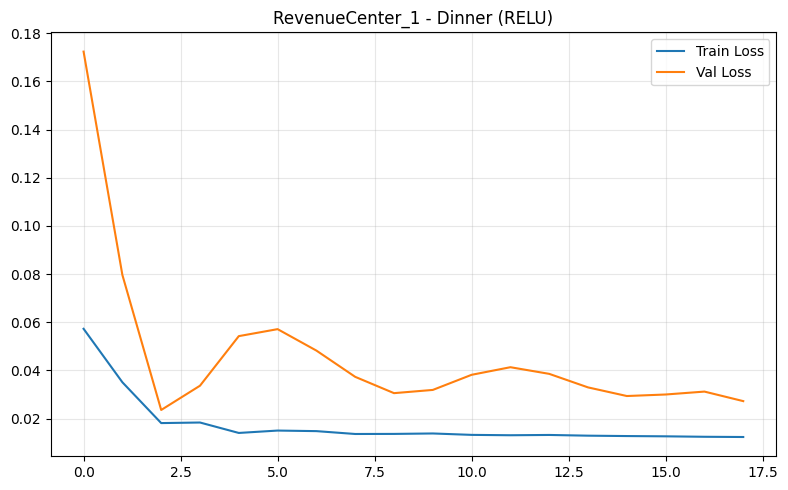

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


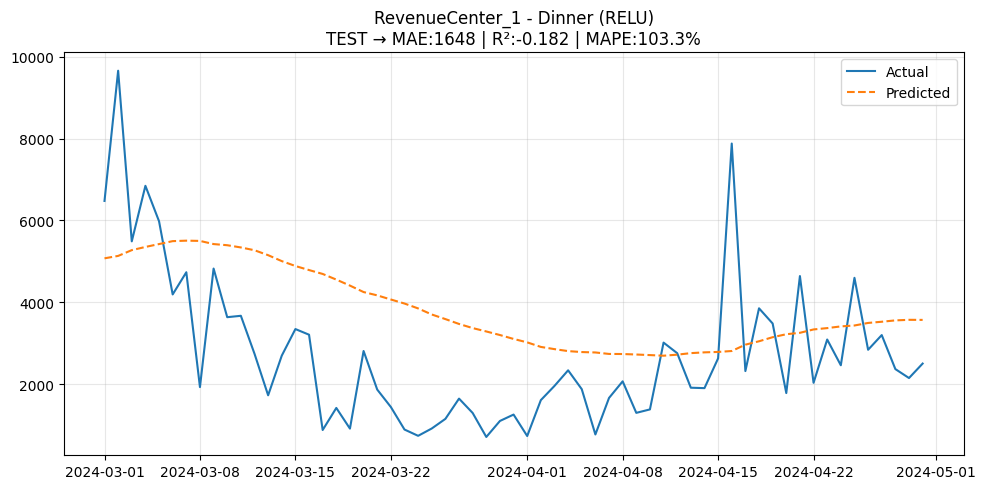

Saved: /content/RevenueCenter_1

ALL CENTERS COMPLETED — RELU MODEL


In [16]:
for file in files:

    center_name = os.path.basename(file).replace(".xlsx", "")
    print("\nProcessing:", center_name)

    center_path = os.path.join(output_folder, center_name)
    os.makedirs(center_path, exist_ok=True)

    df = pd.read_excel(file)
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)

    split_date = df["Date"].max() - pd.DateOffset(months=2)
    meals = ["BreakFast", "Lunch", "Dinner"]

    for meal in meals:

        temp_df = df[["Date", meal]].copy()
        temp_df.rename(columns={meal: "y"}, inplace=True)

        train_df = temp_df[temp_df["Date"] <= split_date]
        test_df  = temp_df[temp_df["Date"] > split_date]



        scaler = MinMaxScaler()
        train_scaled = scaler.fit_transform(train_df[["y"]])
        test_scaled  = scaler.transform(test_df[["y"]])

        WINDOW = 30
        X_train, y_train = create_sequences(train_scaled, WINDOW)
        combined = np.vstack([train_scaled[-WINDOW:], test_scaled])
        X_test, y_test = create_sequences(combined, WINDOW)

        X_train = X_train.reshape(-1, WINDOW, 1)
        X_test  = X_test.reshape(-1, WINDOW, 1)

        # =========================
        # MODEL — RELU
        # =========================
        model = Sequential([
            LSTM(
                256,
                activation="relu",
                recurrent_activation="sigmoid",
                input_shape=(WINDOW, 1)
            ),
            Dense(1)
        ])

        model.compile(optimizer="adam", loss="mse")

        early_stop = EarlyStopping(
            monitor="val_loss",
            patience=15,
            restore_best_weights=True
        )

        history = model.fit(
            X_train, y_train,
            epochs=300,
            batch_size=128,
            validation_split=0.1,
            callbacks=[early_stop],
            verbose=1
        )

        # =========================
        # LOSS PLOT
        # =========================
        plt.figure(figsize=(8,5))
        plt.plot(history.history["loss"], label="Train Loss")
        plt.plot(history.history["val_loss"], label="Val Loss")
        plt.title(f"{center_name} - {meal} (RELU)")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(center_path, f"{meal}_loss_relu.png"), dpi=300)
        plt.show()
        plt.close()

        # =========================
        # PREDICTIONS
        # =========================
        y_train_pred = scaler.inverse_transform(model.predict(X_train))
        y_test_pred  = scaler.inverse_transform(model.predict(X_test))
        y_train_true = scaler.inverse_transform(y_train.reshape(-1,1))
        y_test_true  = scaler.inverse_transform(y_test.reshape(-1,1))

        train_mae  = mean_absolute_error(y_train_true, y_train_pred)
        train_r2   = r2_score(y_train_true, y_train_pred)
        train_mape = mape(y_train_true, y_train_pred)

        test_mae  = mean_absolute_error(y_test_true, y_test_pred)
        test_r2   = r2_score(y_test_true, y_test_pred)
        test_mape = mape(y_test_true, y_test_pred)

        plt.figure(figsize=(10,5))
        plt.plot(test_df["Date"], y_test_true, label="Actual")
        plt.plot(test_df["Date"], y_test_pred, "--", label="Predicted")
        plt.title(
            f"{center_name} - {meal} (RELU)\n"
            f"TEST → MAE:{test_mae:.0f} | R²:{test_r2:.3f} | MAPE:{test_mape:.1f}%"
        )
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(center_path, f"{meal}_pred_tanh.png"), dpi=300)
        plt.show()
        plt.close()

    print("Saved:", center_path)

print("\nALL CENTERS COMPLETED — RELU MODEL")
